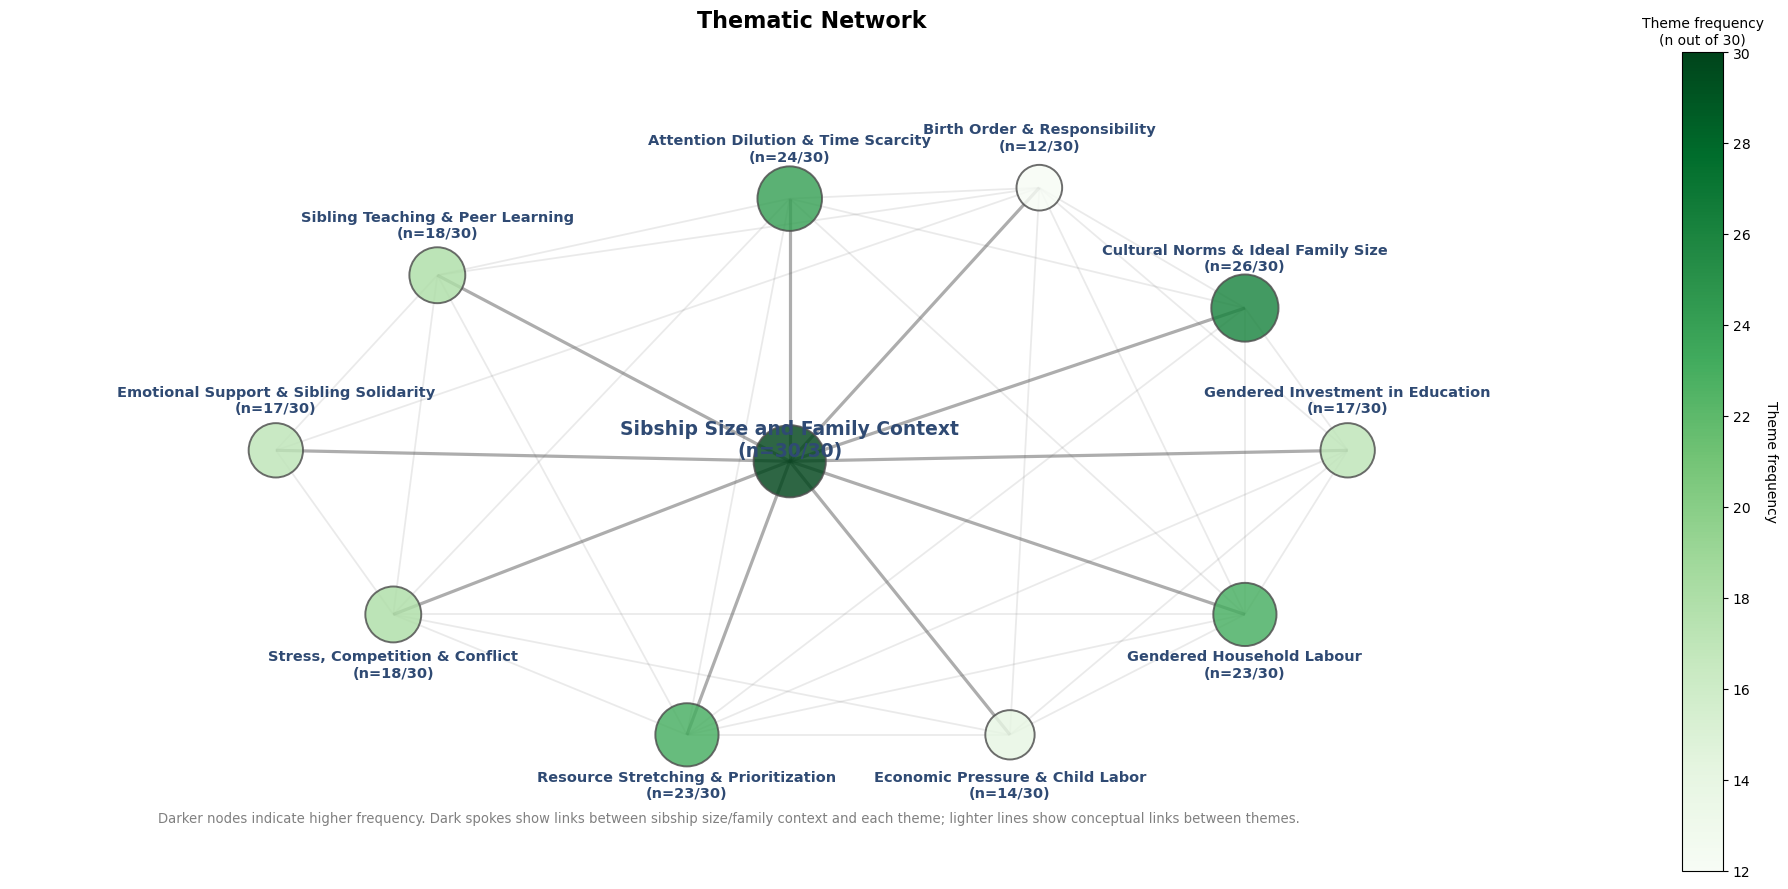

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import os

os.chdir(r"X:\MyProject")

# ----------------------------
# Theme frequencies - UPDATED
# ----------------------------
themes = {
    "Sibship Size and Family Context": 30,   # central concept

    "Attention Dilution & Time Scarcity": 24,
    "Sibling Teaching & Peer Learning": 18,
    "Gendered Investment in Education": 17,
    "Resource Stretching & Prioritization": 23,
    "Birth Order & Responsibility": 12,
    "Gendered Household Labour": 23,
    "Economic Pressure & Child Labor": 14,
    "Emotional Support & Sibling Solidarity": 17,
    "Stress, Competition & Conflict": 18,
    "Cultural Norms & Ideal Family Size": 26
}

# ----------------------------
# Create graph
# ----------------------------
G = nx.Graph()

for theme, freq in themes.items():
    G.add_node(theme, freq=freq)

central = "Sibship Size and Family Context"

# ----------------------------
# Core spoke connections
# ----------------------------
spoke_edges = [
    (central, "Attention Dilution & Time Scarcity"),
    (central, "Sibling Teaching & Peer Learning"),
    (central, "Gendered Investment in Education"),
    (central, "Resource Stretching & Prioritization"),
    (central, "Birth Order & Responsibility"),
    (central, "Gendered Household Labour"),
    (central, "Economic Pressure & Child Labor"),
    (central, "Emotional Support & Sibling Solidarity"),
    (central, "Stress, Competition & Conflict"),
    (central, "Cultural Norms & Ideal Family Size")
]

# ----------------------------
# Conceptual theme links
# ----------------------------
outer_edges = [
    # Cultural norms and family-size meanings
    ("Cultural Norms & Ideal Family Size", "Gendered Investment in Education"),
    ("Cultural Norms & Ideal Family Size", "Gendered Household Labour"),
    ("Cultural Norms & Ideal Family Size", "Birth Order & Responsibility"),
    ("Cultural Norms & Ideal Family Size", "Resource Stretching & Prioritization"),
    ("Cultural Norms & Ideal Family Size", "Attention Dilution & Time Scarcity"),

    # Time, attention, and family responsibilities
    ("Attention Dilution & Time Scarcity", "Resource Stretching & Prioritization"),
    ("Attention Dilution & Time Scarcity", "Birth Order & Responsibility"),
    ("Attention Dilution & Time Scarcity", "Sibling Teaching & Peer Learning"),
    ("Attention Dilution & Time Scarcity", "Gendered Household Labour"),
    ("Attention Dilution & Time Scarcity", "Stress, Competition & Conflict"),

    # Sibling roles
    ("Sibling Teaching & Peer Learning", "Birth Order & Responsibility"),
    ("Sibling Teaching & Peer Learning", "Emotional Support & Sibling Solidarity"),
    ("Sibling Teaching & Peer Learning", "Resource Stretching & Prioritization"),
    ("Sibling Teaching & Peer Learning", "Stress, Competition & Conflict"),

    # Gendered pathways
    ("Gendered Investment in Education", "Gendered Household Labour"),
    ("Gendered Investment in Education", "Resource Stretching & Prioritization"),
    ("Gendered Investment in Education", "Birth Order & Responsibility"),
    ("Gendered Investment in Education", "Economic Pressure & Child Labor"),

    # Scarcity and economic pressure
    ("Resource Stretching & Prioritization", "Economic Pressure & Child Labor"),
    ("Resource Stretching & Prioritization", "Stress, Competition & Conflict"),
    ("Resource Stretching & Prioritization", "Gendered Household Labour"),

    # Birth order and responsibility
    ("Birth Order & Responsibility", "Gendered Household Labour"),
    ("Birth Order & Responsibility", "Economic Pressure & Child Labor"),
    ("Birth Order & Responsibility", "Emotional Support & Sibling Solidarity"),

    # Labour, pressure, and stress
    ("Gendered Household Labour", "Economic Pressure & Child Labor"),
    ("Gendered Household Labour", "Stress, Competition & Conflict"),

    # Emotional and negative sibling dynamics
    ("Emotional Support & Sibling Solidarity", "Stress, Competition & Conflict"),

    # Poverty/pressure and conflict
    ("Economic Pressure & Child Labor", "Stress, Competition & Conflict")
]

for u, v in spoke_edges:
    G.add_edge(u, v, type="core")

for u, v in outer_edges:
    G.add_edge(u, v, type="concept")

# ----------------------------
# Node positions
# Center = Sibship Size and Family Context
# 10 themes around it
# ----------------------------
pos = {
    "Sibship Size and Family Context": (0, 0),

    "Attention Dilution & Time Scarcity": (0.00, 1.20),
    "Birth Order & Responsibility": (0.85, 1.25),
    "Cultural Norms & Ideal Family Size": (1.55, 0.70),
    "Gendered Investment in Education": (1.90, 0.05),
    "Gendered Household Labour": (1.55, -0.70),
    "Economic Pressure & Child Labor": (0.75, -1.25),
    "Resource Stretching & Prioritization": (-0.35, -1.25),
    "Stress, Competition & Conflict": (-1.35, -0.70),
    "Emotional Support & Sibling Solidarity": (-1.75, 0.05),
    "Sibling Teaching & Peer Learning": (-1.20, 0.85)
}

# ----------------------------
# Node size and color
# ----------------------------
node_sizes = [themes[n] * 90 for n in G.nodes()]
node_colors = [themes[n] for n in G.nodes()]

cmap = plt.cm.Greens
norm = Normalize(vmin=min(themes.values()), vmax=max(themes.values()))

# ----------------------------
# Create figure
# ----------------------------
fig, ax = plt.subplots(figsize=(18, 9))

# Conceptual edges - lighter
concept_edges = [(u, v) for u, v, d in G.edges(data=True) if d["type"] == "concept"]
nx.draw_networkx_edges(
    G, pos,
    edgelist=concept_edges,
    width=1.3,
    alpha=0.16,
    edge_color="gray",
    ax=ax
)

# Core edges - darker
core_edges = [(u, v) for u, v, d in G.edges(data=True) if d["type"] == "core"]
nx.draw_networkx_edges(
    G, pos,
    edgelist=core_edges,
    width=2.3,
    alpha=0.45,
    edge_color="#4a4a4a",
    ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=cmap,
    vmin=min(themes.values()),
    vmax=max(themes.values()),
    edgecolors="#4d4d4d",
    linewidths=1.4,
    alpha=0.82,
    ax=ax
)

# ----------------------------
# Labels: upper nodes above, lower nodes below
# ----------------------------
TOTAL_N = 30

for node, (x, y) in pos.items():
    freq = G.nodes[node]["freq"]
    label = f"{node}\n(n={freq}/{TOTAL_N})"

    if node == central:
        ax.text(
            x, y + 0.10, label,
            ha="center", va="center",
            fontsize=13.5,
            fontweight="bold",
            color="#2f4a73"
        )

    elif y >= 0:
        ax.text(
            x, y + 0.16, label,
            ha="center", va="bottom",
            fontsize=10.5,
            fontweight="bold",
            color="#2f4a73"
        )

    else:
        ax.text(
            x, y - 0.16, label,
            ha="center", va="top",
            fontsize=10.5,
            fontweight="bold",
            color="#2f4a73"
        )

# ----------------------------
# Color legend
# ----------------------------
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.04)
cbar.set_label("Theme frequency", rotation=270, labelpad=20)
cbar.ax.set_title("Theme frequency\n(n out of 30)", fontsize=10)

# ----------------------------
# Title and note
# ----------------------------
ax.set_title(
    "Thematic Network",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.text(
    -2.15, -1.65,
    "Darker nodes indicate higher frequency. Dark spokes show links between sibship size/family context and each theme; lighter lines show conceptual links between themes.",
    fontsize=9.5,
    color="gray"
)

ax.axis("off")
ax.margins(0.18)
plt.tight_layout()

# ----------------------------
# Save figure
# ----------------------------
plt.savefig("thematic_network_sibship_center_corrected.png", dpi=300, bbox_inches="tight")
plt.savefig("thematic_network_sibship_center_corrected.pdf", dpi=300, bbox_inches="tight")

plt.show()